In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set premium aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

📊 Dataset Sample:
   User ID    Device Model Operating System  App Usage Time (min/day)  \
0        1  Google Pixel 5          Android                       393   
1        2       OnePlus 9          Android                       268   
2        3    Xiaomi Mi 11          Android                       154   
3        4  Google Pixel 5          Android                       239   
4        5       iPhone 12              iOS                       187   

   Screen On Time (hours/day)  Battery Drain (mAh/day)  \
0                         6.4                     1872   
1                         4.7                     1331   
2                         4.0                      761   
3                         4.8                     1676   
4                         4.3                     1367   

   Number of Apps Installed  Data Usage (MB/day)  Age  Gender  \
0                        67                 1122   40    Male   
1                        42                  944   47  Female   

c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


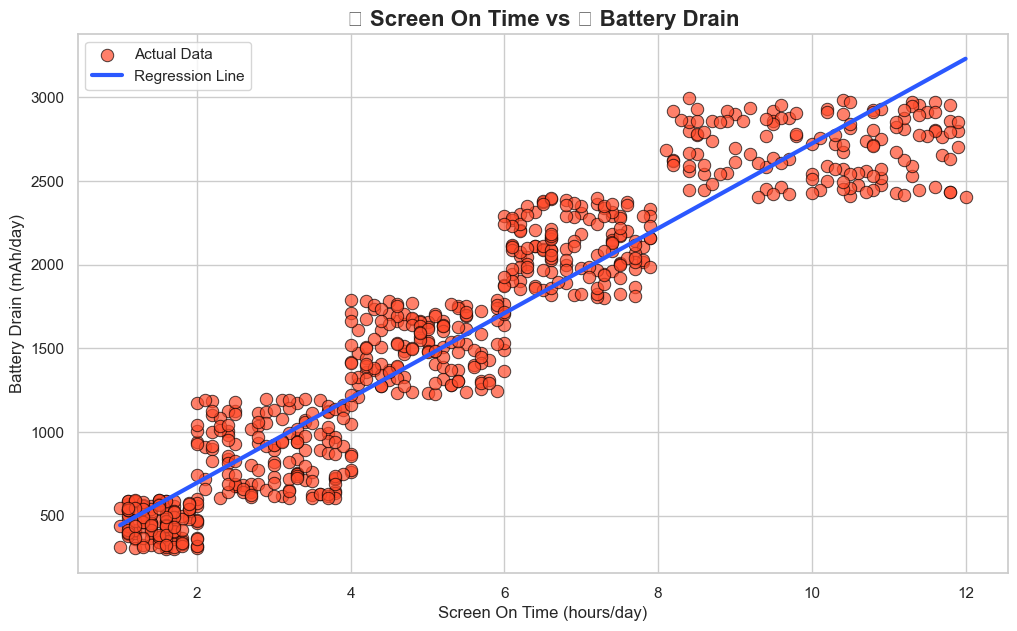


📊 R² Score: 0.9006
📊 MSE     : 66621.35


In [2]:
# Load the dataset
df = pd.read_csv('user_behavior_dataset.csv')

print("📊 Dataset Sample:")
print(df.head())

# Prepare X and y
X = df[['Screen On Time (hours/day)']].values
y = df['Battery Drain (mAh/day)'].values

# Train Linear Regression model
model = LinearRegression()
model.fit(X, y)

print(f"\n✅ Model trained successfully.")
print(f"📐 Formula: Battery Drain = {model.coef_[0]:.4f} × Screen On Time + {model.intercept_:.4f}")

# Generate smooth regression line
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_range_pred = model.predict(X_range)

# Plot
sns.scatterplot(x=df['Screen On Time (hours/day)'], y=df['Battery Drain (mAh/day)'],
                color='#ff4b2b', s=80, edgecolor='black', alpha=0.7, label='Actual Data')
plt.plot(X_range, y_range_pred, color='#2b58ff', linewidth=3, label='Regression Line')

plt.title('📱 Screen On Time vs 🔋 Battery Drain', fontsize=16, fontweight='bold')
plt.xlabel('Screen On Time (hours/day)', fontsize=12)
plt.ylabel('Battery Drain (mAh/day)', fontsize=12)
plt.legend()
plt.show()

# Evaluation
y_pred = model.predict(X)
print(f"\n📊 R² Score: {r2_score(y, y_pred):.4f}")
print(f"📊 MSE     : {mean_squared_error(y, y_pred):.2f}")

In [3]:
def predict_battery_drain(screen_hours):
    prediction = model.predict([[screen_hours]])[0]
    print(f"\n🔮 Prediction for Screen On Time = {screen_hours} hrs/day:")
    print(f"   Estimated Battery Drain: {prediction:,.2f} mAh/day")

try:
    user_hours = float(input("Enter Screen On Time (hours/day): "))
    predict_battery_drain(user_hours)
except ValueError:
    print("❌ Invalid input! Please enter a numeric value.")


🔮 Prediction for Screen On Time = 5.0 hrs/day:
   Estimated Battery Drain: 1,456.07 mAh/day
